# Predicting Customer Churn in Streaming Services

This project analyzes customer data to identify patterns in churn behavior and build machine learning models to predict which customers are likely to leave a streaming service. The goal is to support better customer retention strategies using data-driven insights.

## Data Understanding

The dataset contains customer information such as age, gender, tenure, subscription details, and usage behavior. The target variable is **Churn**, which indicates whether a customer stayed or left the service.

In [3]:
# import basic data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import libraries needed for data processing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
# load data
train_df = pd.read_csv("cctraining.csv")
test_df = pd.read_csv("cctesting.csv")

## Data Cleaning

The dataset was cleaned by removing missing values and duplicate rows. This step ensures the data is accurate and prevents errors during analysis.

In [6]:
# remove duplicate rows
train_df = train_df.drop_duplicates()

# remove rows with missing values
train_df = train_df.dropna()

# check again
print(train_df.isnull().sum())
print(train_df.shape)

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64
(440832, 12)


In [7]:
# Preview data
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)
print(train_df.head())
print(train_df.info())

Training data shape: (440832, 12)
Testing data shape: (64374, 12)
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3

In [8]:
# Check column names (train_df)
print("Columns:")
print(train_df.columns)

Columns:
Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [9]:
# Check missing values
print("\nMissing values in training data:")
print(train_df.isnull().sum())


Missing values in training data:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [10]:
# Drop duplicates (if needed)
train_df = train_df.drop_duplicates()

## Exploratory Data Analysis (EDA)

Charts were created to explore patterns in customer behavior. These visualizations help identify trends related to churn, such as differences by gender, age, and tenure.

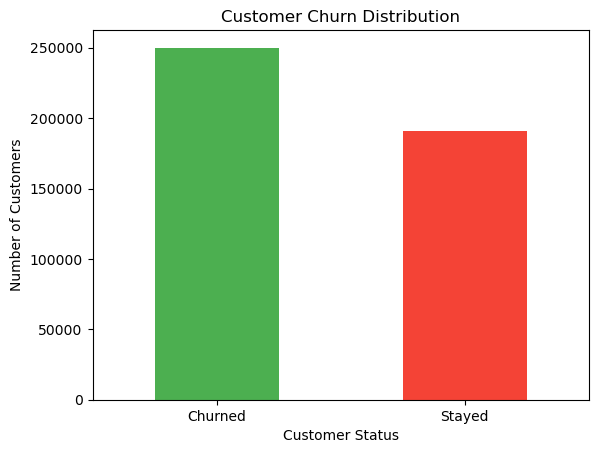

Accuracy: 0.8964238320460036

Confusion Matrix:
[[34546  3517]
 [ 5615 44489]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.91      0.88     38063
         1.0       0.93      0.89      0.91     50104

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167



/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# drop ID column
train_df = train_df.drop(columns=["CustomerID"], errors="ignore")

# create a bar chart to show how many customers stayed vs churned
churn_labels = train_df["Churn"].map({0: "Stayed", 1: "Churned"})

churn_labels.value_counts().plot(kind="bar", color=["#4CAF50", "#F44336"])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

# separate the dataset into features (X) and target variable (y)

# X = input variables used for prediction
X = train_df.drop("Churn", axis=1)

# y = churn (what the model is trying to predict)
y = train_df["Churn"]

# convert categorical (text) columns into numerical format
X = pd.get_dummies(X, drop_first=True)

# split the data into training and testing sets
# training data is used to build the model
# testing data is used to evaluate performance on new data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train a Logistic Regression model as a baseline model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# use the model to make predictions on the test data
y_pred = model.predict(X_test)

# evaluate the model using performance metrics

# accuracy = overall correct predictions
print("Accuracy:", accuracy_score(y_test, y_pred))

# confusion Matrix = shows correct vs incorrect predictions
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# classification Report = includes precision, recall, and F1 score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [13]:
# calculate the percentage churned vs stayed
train_df['Churn'].value_counts(normalize=True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

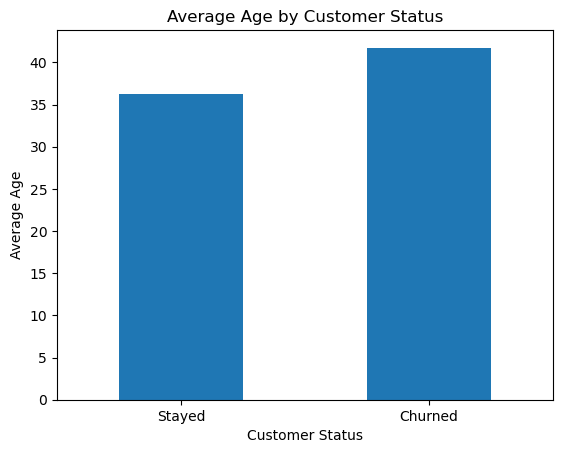

In [14]:
# calculate the average age for customers who stayed vs churned
age_churn = train_df.groupby("Churn")["Age"].mean()

# rename the labels to make the chart easier to understand
age_churn.index = ["Stayed", "Churned"]

# create a bar chart to compare average age between the two groups
age_churn.plot(kind="bar")

plt.title("Average Age by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Age")

plt.xticks(rotation=0)
plt.show()

In [15]:
# calculate age churn mean
age_churn = train_df.groupby('Churn')['Age'].mean()
print(age_churn)

Churn
0.0    36.262973
1.0    41.747263
Name: Age, dtype: float64


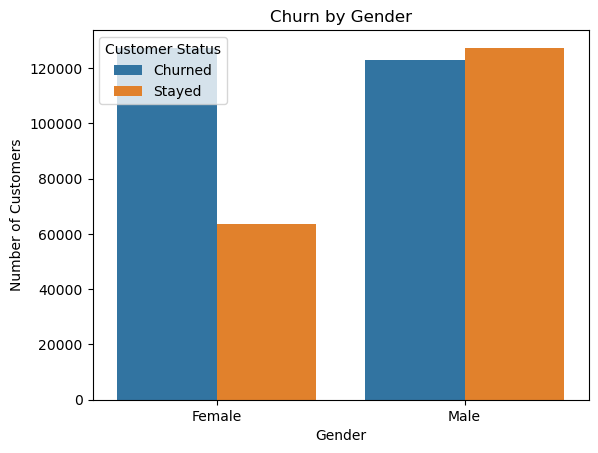

In [16]:
# create a new column "Churn_Label" with readable labels for churn
train_df["Churn_Label"] = train_df["Churn"].map({0: "Stayed", 1: "Churned"})

# create a count plot to compare churn by gender
sns.countplot(x="Gender", hue="Churn_Label", data=train_df)

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status")
plt.show()

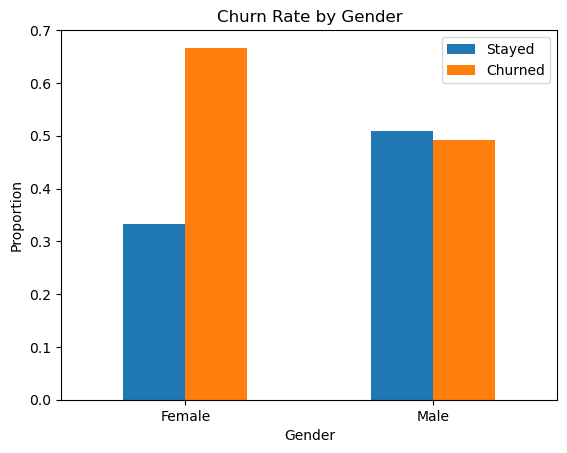

In [17]:
# create a table showing the proportion of customers who stayed vs churned for each gender
gender_churn = pd.crosstab(train_df["Gender"], train_df["Churn"], normalize="index")

# plot the results as a bar chart
gender_churn.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")

plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()

In [18]:
# calculate gender churn %
gender_churn = train_df.groupby('Gender')['Churn'].value_counts(normalize=True)
gender_churn

Gender  Churn
Female  1.0      0.666691
        0.0      0.333309
Male    0.0      0.508731
        1.0      0.491269
Name: proportion, dtype: float64

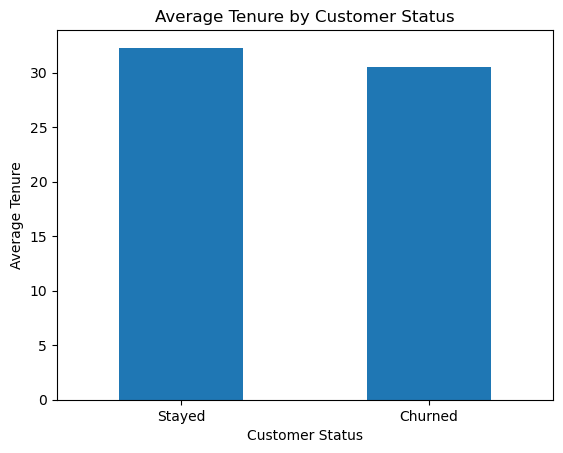

In [19]:
# calculate the average tenure for customers who stayed vs churned
tenure_churn = train_df.groupby("Churn")["Tenure"].mean()

# rename labels to make the chart easier to read
tenure_churn.index = ["Stayed", "Churned"]

# create a bar chart to compare average tenure
tenure_churn.plot(kind="bar")

plt.title("Average Tenure by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Tenure")

plt.xticks(rotation=0)
plt.show()

In [20]:
# calculate tenure churn mean
tenure_churn = train_df.groupby('Churn')['Tenure'].mean()
print(tenure_churn)

Churn
0.0    32.281754
1.0    30.473598
Name: Tenure, dtype: float64


## Feature Selection

Feature selection was applied to remove variables that could negatively affect the model. 
This step helps improve model performance and ensures the model learns real patterns instead of memorizing outcomes.

In [22]:
# Separate the dataset into features (X) and target variable (y)
# Remove columns that should not be used in the model

# X = input variables used to predict churn
X = train_df.drop(columns=["Churn", # 'Churn_Label' is removed because it directly matches the target (data leakage)
                           "CustomerID", # 'CustomerID' is removed because it does not provide useful information
                           "Churn_Label", "Last Interaction" # 'Last Interaction' is removed to avoid overly strong or unrealistic predictions
                          ], errors="ignore")

# y = churn (the outcome being predicted)
y = train_df["Churn"]

## Data Preparation
The dataset was split into features (X) and the target variable (y). Categorical variables were converted into numerical format using one-hot encoding. The data was then split into training and testing sets to evaluate model performance on unseen data.

In [24]:
# split data into training (80%) and testing (20%)
# training data = build the model
# testing data = evaluate performance on new data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# convert categorical (text) columns into numerical format using one-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# make sure both training and testing datasets have the same columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0) # if a category is missing in the test set, fill with 0

## Model Building

Three machine learning models were tested to predict customer churn:
- Logistic Regression (baseline model)
- Decision Tree (captures more complex patterns)
- Random Forest (combines multiple trees for better performance)

These models were compared to determine which performs best.

In [27]:
# train multiple models to compare performance
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=1000), # Logistic Regression is used as a baseline model
    "Decision Tree": DecisionTreeClassifier(random_state=42), # Decision Tree can capture more complex patterns
    "Random Forest": RandomForestClassifier(random_state=42) # Random Forest combines multiple trees for better predictions
}

# loop through each model, train it, and evaluate performance
for name, model in models.items():
    model.fit(X_train, y_train)  # train model
    y_pred = model.predict(X_test)  # make predictions

    print(name)
    
    # accuracy = overall correct predictions
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    # precision = how many predicted churners actually churned
    print("Precision:", precision_score(y_test, y_pred))
    
    # recall = how many actual churners we correctly found
    print("Recall:", recall_score(y_test, y_pred))
    
    # F1 = balance between precision and recall
    print("F1:", f1_score(y_test, y_pred))
    
    print()

Logistic Regression
Accuracy: 0.8911384077942994
Precision: 0.9227477665525591
Recall: 0.8823048060035127
F1: 0.9020732155246296

Decision Tree
Accuracy: 0.9816824889130854
Precision: 0.9818351650535604
Recall: 0.9860091010697749
F1: 0.983917706455821

Random Forest
Accuracy: 0.9914026790068846
Precision: 0.9999392121899822
Recall: 0.9849313428069615
F1: 0.9923785392535392



## Model Evaluation

Model performance was evaluated using accuracy, precision, recall, and F1 score. Among these metrics, the F1 score is especially important because it balances false positives and false negatives.

The results showed that Random Forest performed the best compared to the other models.

In [29]:
# use the best-performing model (Random Forest) for final evaluation
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

# make predictions
y_pred = best_model.predict(X_test)

# evaluate performance using key metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9914026790068846

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     38063
         1.0       1.00      0.98      0.99     50104

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167



## Final Model Evaluation

The Random Forest model was selected as the best-performing model based on the evaluation metrics. It achieved an accuracy of 0.991, along with strong precision, recall, and F1 scores.

The classification report shows that the model performs well for both churned and non-churned customers, with very few errors. The high F1 score indicates that the model is able to balance correctly identifying churned customers while minimizing incorrect predictions.

These results suggest that the model is effective at predicting customer churn and can be useful for identifying at-risk customers.